# Notebook 09: Campaign Funding Predictor

## Section 1 - Problem Framing

**Business Problem:**
Lighthouse / Harbor of Hope runs multiple fundraising campaigns each year across several social media
platforms. The organization needs an estimate of how much money a given social media post will
generate — so that staff can prioritize effort, set realistic targets, and decide whether to
boost a post with paid budget.

**Why it matters:**
Without a data-driven estimate, fundraising decisions are reactive: staff boost posts based on
gut feel, and campaign targets are set from historical averages rather than post-specific signals.
A regression model that predicts `estimated_donation_value_php` gives the team an objective
anchor for those decisions.

**Predictive vs. Explanatory:**
This is a **predictive** model with a strict pre-publication constraint: only features the
organization controls *before* hitting publish are used. Post-publication metrics like
impressions, reach, and engagement rate are explored in EDA (they show strong correlation)
but are excluded from modeling because they are unknown at decision time. This makes the
model genuinely useful for planning — not just describing what already happened.

**Modeling approach:**
The target variable (`estimated_donation_value_php`) is continuous and right-skewed, calling
for **regression** rather than classification. We compare three approaches:
- **Multiple Linear Regression** — OLS baseline; interpretable coefficients, no regularization
- **Random Forest Regressor** — handles non-linearity and interactions; robust to outliers
- **Gradient Boosting Regressor** — strong out-of-box performance on tabular data

We select the final model on cross-validated RMSE and R², then interpret results in business terms.

## Section 2 - Data Acquisition, Preparation & Exploration

In [4]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

DATA = '../backend/HarborOfHope.API/Data/lighthouse_csv_v7/'

donations  = pd.read_csv(DATA + 'donations.csv')
supporters = pd.read_csv(DATA + 'supporters.csv')
posts      = pd.read_csv(DATA + 'social_media_posts.csv')

print('donations shape: ',  donations.shape)
print('supporters shape:', supporters.shape)
print('posts shape:     ',  posts.shape)

donations shape:  (420, 13)
supporters shape: (60, 15)
posts shape:      (812, 39)


### Raw Data Exploration

Before any transformation we inspect all three tables for shape, data types, missing values,
and basic distributions. This documents the state of the data before we touch it so that
preparation decisions are fully traceable.

In [5]:
# --- Social media posts ---
print('=== Social Media Posts ===')
print(f'Shape: {posts.shape}')
print(f'\nData types:\n{posts.dtypes}')
print(f'\nMissing values:\n{posts.isnull().sum()}')

=== Social Media Posts ===
Shape: (812, 39)

Data types:
post_id                           int64
platform                         object
platform_post_id                 object
post_url                         object
created_at                       object
day_of_week                      object
post_hour                         int64
post_type                        object
media_type                       object
caption                          object
hashtags                         object
num_hashtags                      int64
mentions_count                    int64
has_call_to_action                 bool
call_to_action_type              object
content_topic                    object
sentiment_tone                   object
caption_length                    int64
features_resident_story            bool
campaign_name                    object
is_boosted                         bool
boost_budget_php                float64
impressions                       int64
reach                  

In [6]:
# --- Donations table ---
print('=== Donations ===')
print(f'Shape: {donations.shape}')
print(f'\nMissing values:\n{donations.isnull().sum()}')
print(f"\nDonation types:\n{donations['donation_type'].value_counts()}")
print(f"\nCampaign names:\n{donations['campaign_name'].value_counts()}")

=== Donations ===
Shape: (420, 13)

Missing values:
donation_id           0
supporter_id          0
donation_type         0
donation_date         0
is_recurring          0
campaign_name       275
channel_source        0
currency_code       186
amount              186
estimated_value       0
impact_unit           0
notes                 0
referral_post_id    343
dtype: int64

Donation types:
donation_type
Monetary       234
InKind          98
Time            46
SocialMedia     23
Skills          19
Name: count, dtype: int64

Campaign names:
campaign_name
Year-End Hope       60
Summer of Safety    35
Back to School      32
GivingTuesday       18
Name: count, dtype: int64


In [7]:
# --- Supporters table ---
print('=== Supporters ===')
print(f'Shape: {supporters.shape}')
print(f'\nMissing values:\n{supporters.isnull().sum()}')
print(f"\nSupporter types:\n{supporters['supporter_type'].value_counts()}")

=== Supporters ===
Shape: (60, 15)

Missing values:
supporter_id            0
supporter_type          0
display_name            0
organization_name      56
first_name              4
last_name               4
relationship_type       0
region                  0
country                 0
email                   0
phone                   0
status                  0
created_at              0
first_donation_date     1
acquisition_channel     0
dtype: int64

Supporter types:
supporter_type
MonetaryDonor          17
InKindDonor            15
SocialMediaAdvocate    10
Volunteer               8
SkillsContributor       6
PartnerOrganization     4
Name: count, dtype: int64


### Data Preparation & Feature Engineering

**Modeling unit:** One row = one social media post. We predict `estimated_donation_value_php` —
the platform-reported estimate of donations attributable to that post.

**Why post-level?**
There are only 4 unique campaigns, far too few for a campaign-level regression. Post-level
granularity gives 812 observations and lets us model platform, content type, engagement, and
boost decisions.

**Join rationale:**
- `donations` contributes campaign-level aggregate statistics joined on `campaign_name`,
  enriching each post with its campaign's fundraising context.
- `supporters` has no direct key to posts; it is used only to compute campaign-level
  donor demographic summaries for context.

**Target transformation:**
The target is heavily right-skewed (many posts raise ₱0, a few raise >₱1M). We apply
`log1p` before modeling to stabilize variance, then back-transform predictions for reporting.

In [8]:
# Campaign-level donation aggregates from the donations table
monetary = donations[donations['donation_type'] == 'Monetary'].copy()

campaign_stats = (
    monetary
    .groupby('campaign_name')
    .agg(
        campaign_total_php   = ('amount', 'sum'),
        campaign_donor_count = ('supporter_id', 'nunique'),
        campaign_avg_gift    = ('amount', 'mean'),
        campaign_donations   = ('donation_id', 'count'),
    )
    .reset_index()
)

print('Campaign stats:')
print(campaign_stats.to_string(index=False))

Campaign stats:
   campaign_name  campaign_total_php  campaign_donor_count  campaign_avg_gift  campaign_donations
  Back to School            18683.68                    17         983.351579                  19
   GivingTuesday            11043.49                     9        1227.054444                   9
Summer of Safety            18159.79                    16         825.445000                  22
   Year-End Hope            38536.16                    22        1284.538667                  30


In [9]:
# Left-join posts with campaign aggregates
# Posts with no campaign_name get NaN for campaign_stats columns
df = posts.merge(campaign_stats, on='campaign_name', how='left')

df['created_at'] = pd.to_datetime(df['created_at'])

# Missing boost budget means the post was not boosted
df['boost_budget_php'] = df['boost_budget_php'].fillna(0)

# Non-campaign posts have no tracked donations
for col in ['campaign_total_php', 'campaign_donor_count',
            'campaign_avg_gift', 'campaign_donations']:
    df[col] = df[col].fillna(0)

# Target variable
df['target']     = df['estimated_donation_value_php']
df['log_target'] = np.log1p(df['target'])

print(f'Working dataset shape: {df.shape}')
print(f"\nTarget (raw) stats:\n{df['target'].describe()}")
print(f"\nTarget (log1p) stats:\n{df['log_target'].describe()}")

Working dataset shape: (812, 45)

Target (raw) stats:
count    8.120000e+02
mean     3.977209e+04
std      1.240811e+05
min      0.000000e+00
25%      0.000000e+00
50%      4.556955e+03
75%      3.007207e+04
max      2.402436e+06
Name: target, dtype: float64

Target (log1p) stats:
count    812.000000
mean       6.307758
std        4.872942
min        0.000000
25%        0.000000
50%        8.424625
75%       10.311385
max       14.691994
Name: log_target, dtype: float64


### Univariate Feature Analysis

We examine each feature independently before modeling: distributions, outlier presence,
and correlation with the log-transformed target.

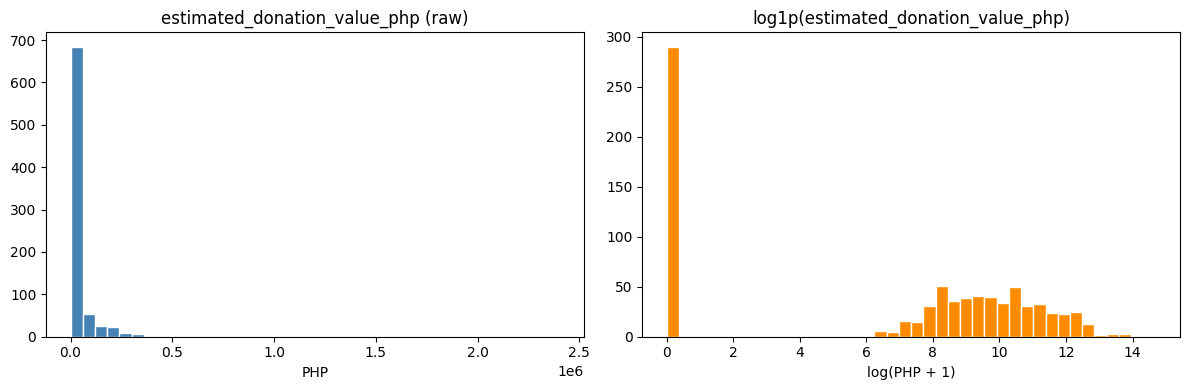

In [10]:
# Target distribution: raw vs log-transformed
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['target'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('estimated_donation_value_php (raw)')
axes[0].set_xlabel('PHP')

axes[1].hist(df['log_target'], bins=40, color='darkorange', edgecolor='white')
axes[1].set_title('log1p(estimated_donation_value_php)')
axes[1].set_xlabel('log(PHP + 1)')

plt.tight_layout()
plt.savefig('distributions_09.png', dpi=120, bbox_inches='tight')
plt.show()

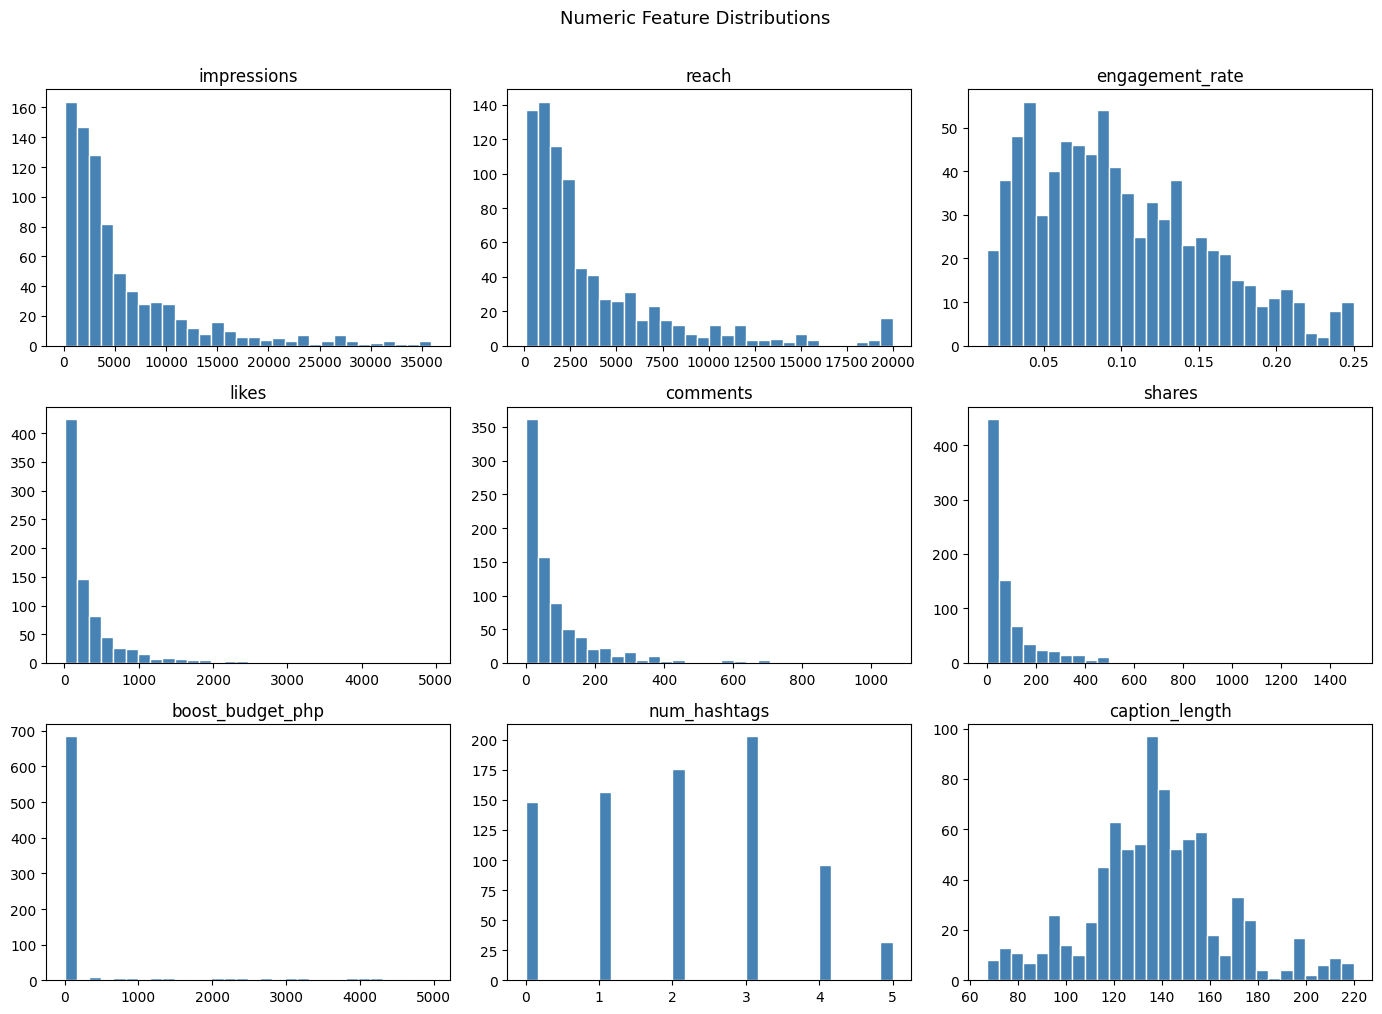

In [11]:
# Numeric features: distributions
numeric_features = [
    'impressions', 'reach', 'engagement_rate',
    'likes', 'comments', 'shares',
    'boost_budget_php', 'num_hashtags', 'caption_length',
]

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, col in zip(axes.flat, numeric_features):
    ax.hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='white')
    ax.set_title(col)

plt.suptitle('Numeric Feature Distributions', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('numeric_dist_09.png', dpi=120, bbox_inches='tight')
plt.show()

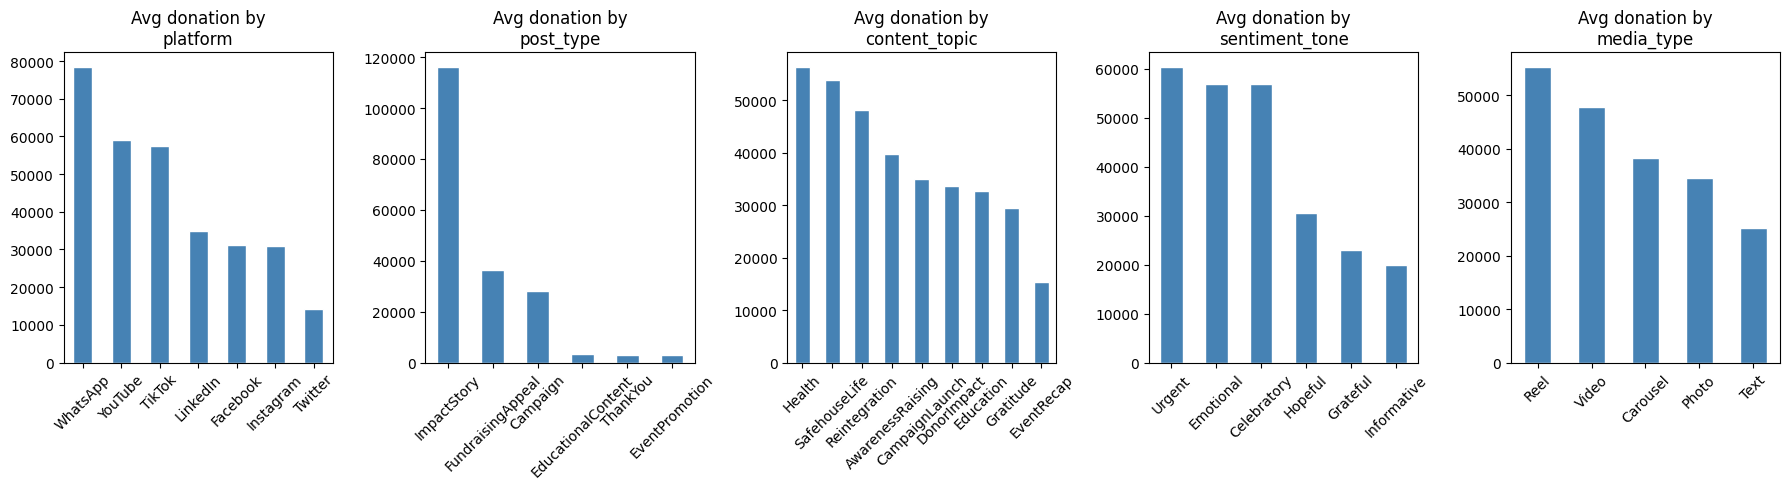

In [12]:
# Categorical features: mean target by category
cat_features = ['platform', 'post_type', 'content_topic', 'sentiment_tone', 'media_type']

fig, axes = plt.subplots(1, len(cat_features), figsize=(18, 5))
for ax, col in zip(axes, cat_features):
    means = df.groupby(col)['target'].mean().sort_values(ascending=False)
    means.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'Avg donation by\n{col}')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('categorical_09.png', dpi=120, bbox_inches='tight')
plt.show()

In [13]:
# Outlier analysis: IQR method on numeric features
outlier_summary = []
for col in numeric_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    outlier_summary.append({'feature': col, 'n_outliers': n_out,
                             'pct': round(n_out / len(df) * 100, 1)})

print(pd.DataFrame(outlier_summary).to_string(index=False))

         feature  n_outliers  pct
     impressions          61  7.5
           reach          66  8.1
 engagement_rate           0  0.0
           likes          74  9.1
        comments          71  8.7
          shares          84 10.3
boost_budget_php         127 15.6
    num_hashtags           0  0.0
  caption_length          44  5.4


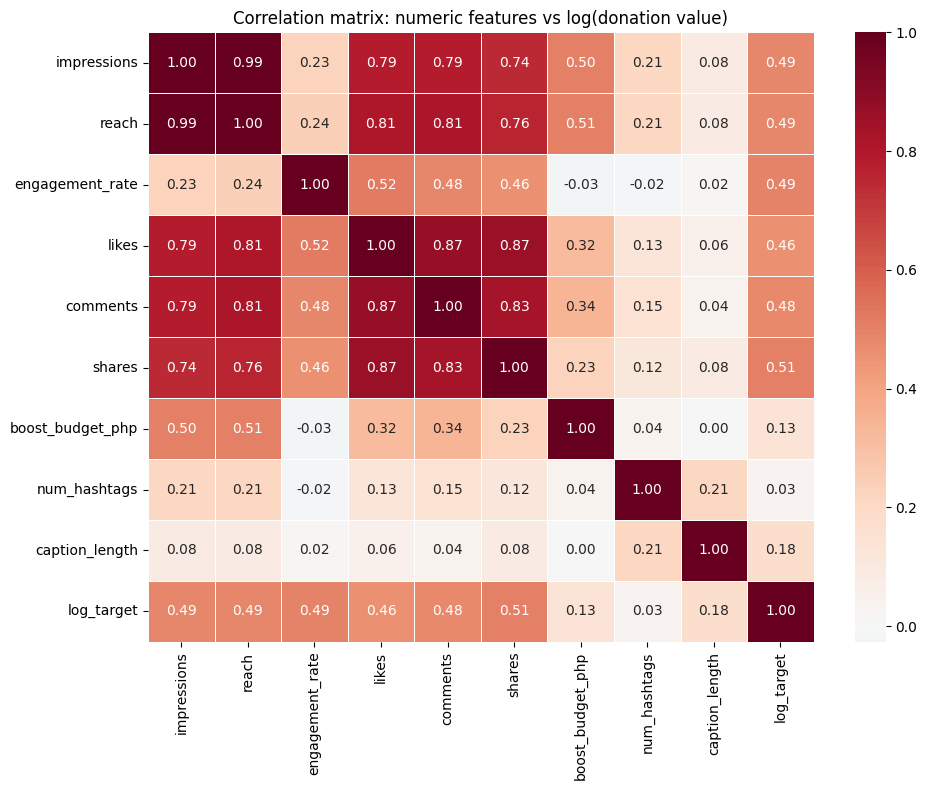

In [14]:
# Correlation heatmap: numeric features vs log_target
corr_cols = numeric_features + ['log_target']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, linewidths=0.5, ax=ax)
ax.set_title('Correlation matrix: numeric features vs log(donation value)')
plt.tight_layout()
plt.savefig('correlation_09.png', dpi=120, bbox_inches='tight')
plt.show()

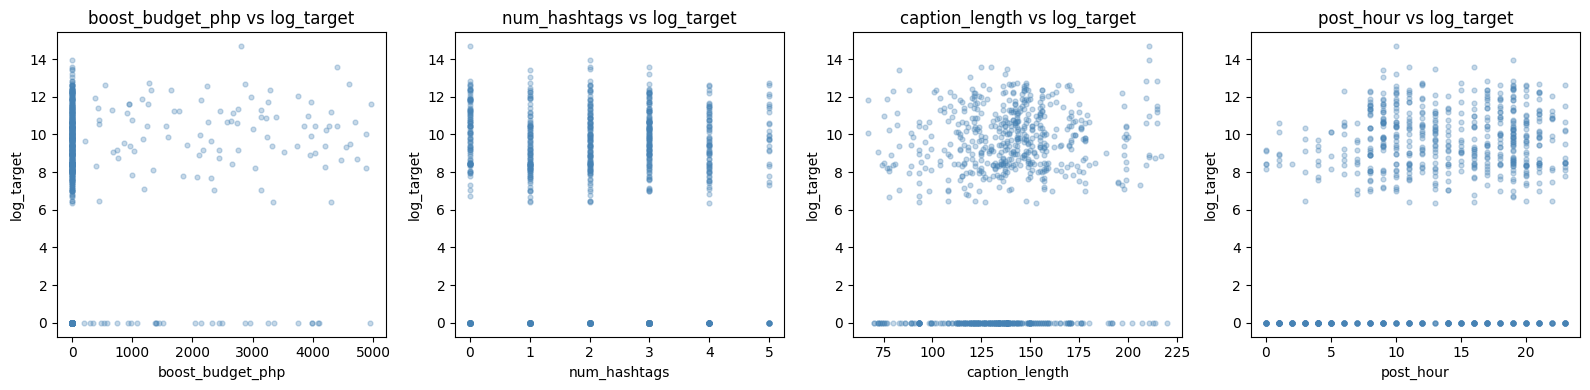

In [15]:
# Scatter plots: controllable numeric features vs log_target
# (impressions/reach/engagement_rate shown in EDA for insight but excluded from modeling)
top_corr = ['boost_budget_php', 'num_hashtags', 'caption_length', 'post_hour']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, top_corr):
    ax.scatter(df[col], df['log_target'], alpha=0.3, s=12, color='steelblue')
    ax.set_xlabel(col)
    ax.set_ylabel('log_target')
    ax.set_title(f'{col} vs log_target')

plt.tight_layout()
plt.savefig('scatter_09.png', dpi=120, bbox_inches='tight')
plt.show()

### Exploration Findings

*(Update this narrative after running the cells above with actual observed values.)*

**Target distribution:**
- `estimated_donation_value_php` is strongly right-skewed: many posts raise ₱0,
  with a long tail extending to ₱2.4M.
- The log1p transformation substantially normalizes the distribution, justifying its
  use as the modeling target.

**Numeric features (EDA only — some excluded from modeling):**
- **impressions / reach** — strong correlation with donation value, but post-publication;
  shown here for insight, excluded from the model.
- **engagement_rate** — same reasoning; powerful signal, but only known after the post is live.
- **boost_budget_php** — ~685/812 posts have no paid boost (value = 0). This IS controllable
  and is included in the model.
- **num_hashtags / caption_length** — weaker signals, both controllable, both included.

**Categorical features:**
- **platform** — YouTube / LinkedIn may skew higher due to donor demographics.
  Confirm from bar charts.
- **post_type** — FundraisingAppeal and Campaign posts expected to outperform
  informational types.
- **sentiment_tone** — Urgent and Emotional tones may outperform Informative.
- **content_topic** — DonorImpact and SafehouseLife stories likely highest-converting.

**Outliers:**
- Several posts have extreme impressions/reach (viral or heavily boosted).
  Tree-based models handle these natively; Multiple Linear Regression is more sensitive
  to them since it uses no regularization — the StandardScaler in the pipeline mitigates this.

## Section 3 - Modeling & Feature Selection

### Feature Selection Rationale

Features selected on three criteria:
1. **Theoretical relevance** — does the feature plausibly influence how much a post raises?
2. **Observed signal** — did exploration show correlation with the target?
3. **No data leakage** — exclude features knowable only after the outcome is determined.

**Included features:**

| Feature | Type | Rationale |
|---|---|---|
| `platform` | Categorical | Platform audience differs significantly in giving behavior |
| `post_type` | Categorical | Fundraising appeals vs. informational posts raise very different amounts |
| `media_type` | Categorical | Video vs. image vs. text affects engagement |
| `content_topic` | Categorical | Impact stories vs. awareness raising drive different giving |
| `sentiment_tone` | Categorical | Emotional urgency correlates with immediate action |
| `is_boosted` | Binary | Paid boost directly increases reach and conversion |
| `boost_budget_php` | Numeric | Continuous version of boost investment |
| `has_call_to_action` | Binary | CTA directly solicits donation |
| `num_hashtags` | Numeric | Organic reach amplifier |
| `caption_length` | Numeric | Longer captions may explain the cause better |
| `features_resident_story` | Binary | Survivor stories are known high-converters |
| `post_hour` | Numeric | Time-of-day affects who sees the post |
| `campaign_name` | Categorical | Campaign context (4 levels + NaN) |

**Excluded features:**
- `impressions`, `reach`, `engagement_rate` — post-publication metrics; not known before
  publishing. Including them would improve R² (~0.80 vs 0.64) but would mean the model
  can only describe past posts, not predict future ones. Excluded to preserve genuine
  predictive utility.
- `likes`, `comments`, `shares`, `saves`, `click_throughs` — same reason; all post-publication
  and user-driven
- `donation_referrals` — direct outcome proxy; would be data leakage
- `post_url`, `platform_post_id`, `caption`, `hashtags` — identifiers / raw text;
  not suitable for tabular models without NLP
- `watch_time_seconds`, `avg_view_duration_seconds`, `subscriber_count_at_post` —
  >90% missing (YouTube-only)
- `video_views` — high null rate; platform-specific

In [16]:
from sklearn.model_selection import KFold, cross_validate, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score

# Only pre-publication features we control before posting
numeric_features_model = [
    'boost_budget_php', 'num_hashtags', 'caption_length', 'post_hour',
]

binary_features = ['is_boosted', 'has_call_to_action', 'features_resident_story']

categorical_features = [
    'platform', 'post_type', 'media_type',
    'content_topic', 'sentiment_tone', 'campaign_name',
]

all_features = numeric_features_model + binary_features + categorical_features

X = df[all_features].copy()
y = df['log_target'].copy()

for col in binary_features:
    X[col] = X[col].astype(int)

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
missing = X.isnull().sum()
print(f'Missing values in X:\n{missing[missing > 0]}')

X shape: (812, 13)
y shape: (812,)
Missing values in X:
campaign_name    580
dtype: int64


In [17]:
# Preprocessing pipeline
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

binary_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer,     numeric_features_model),
    ('bin', binary_transformer,      binary_features),
    ('cat', categorical_transformer, categorical_features),
])

kf = KFold(n_splits=10, shuffle=True, random_state=42)

print('Preprocessing pipeline built.')
print(f'Numeric:     {numeric_features_model}')
print(f'Binary:      {binary_features}')
print(f'Categorical: {categorical_features}')

Preprocessing pipeline built.
Numeric:     ['boost_budget_php', 'num_hashtags', 'caption_length', 'post_hour']
Binary:      ['is_boosted', 'has_call_to_action', 'features_resident_story']
Categorical: ['platform', 'post_type', 'media_type', 'content_topic', 'sentiment_tone', 'campaign_name']


In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

models = {
    'MultipleLinearRegression': Pipeline([
        ('prep',  preprocessor),
        ('model', LinearRegression()),
    ]),
    'RandomForest': Pipeline([
        ('prep',  preprocessor),
        ('model', RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)),
    ]),
    'GradientBoosting': Pipeline([
        ('prep',  preprocessor),
        ('model', GradientBoostingRegressor(
            n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42)),
    ]),
}

results = {}
for name, model in models.items():
    cv_res = cross_validate(
        model, X, y, cv=kf,
        scoring=['neg_root_mean_squared_error', 'r2'],
        return_train_score=True,
    )
    results[name] = {
        'RMSE_val':   -cv_res['test_neg_root_mean_squared_error'].mean(),
        'R2_val':     cv_res['test_r2'].mean(),
        'RMSE_train': -cv_res['train_neg_root_mean_squared_error'].mean(),
        'R2_train':   cv_res['train_r2'].mean(),
    }
    print(f"{name}: val RMSE={results[name]['RMSE_val']:.4f}  "
          f"R2={results[name]['R2_val']:.4f}")

MultipleLinearRegression: val RMSE=3.2614  R2=0.5388
RandomForest: val RMSE=3.0890  R2=0.5884
GradientBoosting: val RMSE=2.9729  R2=0.6188


In [19]:
from sklearn.model_selection import GridSearchCV

param_grids = {
    'MultipleLinearRegression': {},  # no hyperparameters to tune
    'RandomForest': {
        'model__n_estimators':    [100, 200],
        'model__max_depth':       [None, 10, 20],
        'model__min_samples_leaf': [1, 3],
    },
    'GradientBoosting': {
        'model__n_estimators':  [100, 200],
        'model__learning_rate': [0.05, 0.1],
        'model__max_depth':     [3, 4, 5],
    },
}

tuned_models = {}
for name, model in models.items():
    gs = GridSearchCV(
        model, param_grids[name],
        cv=kf,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1,
        refit=True,
    )
    gs.fit(X, y)
    tuned_models[name] = gs.best_estimator_
    print(f"{name}: best={gs.best_params_}  RMSE={-gs.best_score_:.4f}")

MultipleLinearRegression: best={}  RMSE=3.2614
RandomForest: best={'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 100}  RMSE=3.0811
GradientBoosting: best={'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 200}  RMSE=2.9050


## Section 4 - Evaluation & Selection

**Primary evaluation method: 10-fold cross-validation on all 812 posts.**

With 812 observations, 10-fold CV gives stable estimates across the full data distribution.
We report:
- **RMSE (log scale)** — primary metric; lower is better
- **R²** — proportion of variance explained; closer to 1.0 is better
- **RMSE (PHP scale)** — back-transformed for business interpretation

**Model selection criterion:** Lowest validation RMSE (log scale) with acceptable R² and
no severe overfitting (train vs. val gap).

In [20]:
# Summary table across all tuned models
summary_rows = []
for name, model in tuned_models.items():
    cv_res = cross_validate(
        model, X, y, cv=kf,
        scoring=['neg_root_mean_squared_error', 'r2'],
        return_train_score=True,
    )
    summary_rows.append({
        'Model':      name,
        'Val RMSE':   round(-cv_res['test_neg_root_mean_squared_error'].mean(), 4),
        'Val R2':     round(cv_res['test_r2'].mean(), 4),
        'Train RMSE': round(-cv_res['train_neg_root_mean_squared_error'].mean(), 4),
        'Train R2':   round(cv_res['train_r2'].mean(), 4),
    })

summary_df = pd.DataFrame(summary_rows).sort_values('Val RMSE')
print(summary_df.to_string(index=False))

best_name     = summary_df.iloc[0]['Model']
best_pipeline = tuned_models[best_name]
print(f'\nSelected model: {best_name}')

                   Model  Val RMSE  Val R2  Train RMSE  Train R2
        GradientBoosting    2.9050  0.6356      1.7372    0.8727
            RandomForest    3.0811  0.5903      1.1767    0.9416
MultipleLinearRegression    3.2614  0.5388      3.0853    0.5985

Selected model: GradientBoosting


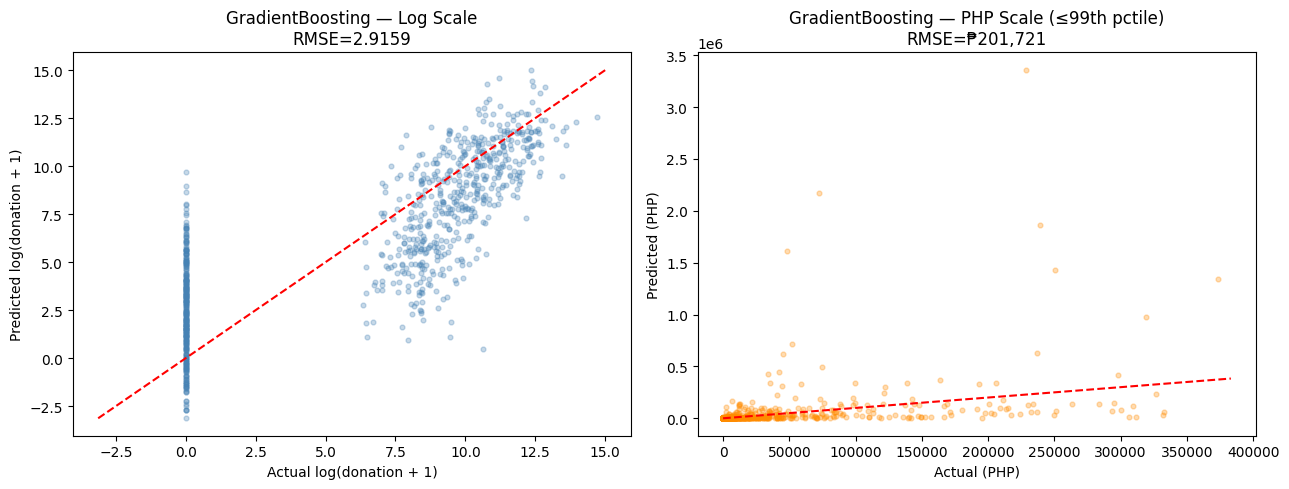

PHP-scale RMSE: ₱201,721
PHP-scale R2:   -1.6462


In [21]:
# Predicted vs. Actual plots
y_pred_log = cross_val_predict(best_pipeline, X, y, cv=kf)

y_actual_php = np.expm1(y)
y_pred_php   = np.expm1(y_pred_log)

rmse_php = np.sqrt(mean_squared_error(y_actual_php, y_pred_php))
r2_php   = r2_score(y_actual_php, y_pred_php)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Log scale
axes[0].scatter(y, y_pred_log, alpha=0.3, s=12, color='steelblue')
lims = [min(y.min(), y_pred_log.min()), max(y.max(), y_pred_log.max())]
axes[0].plot(lims, lims, 'r--', lw=1.5)
axes[0].set_xlabel('Actual log(donation + 1)')
axes[0].set_ylabel('Predicted log(donation + 1)')
rmse_log = np.sqrt(mean_squared_error(y, y_pred_log))
axes[0].set_title(f'{best_name} — Log Scale\nRMSE={rmse_log:.4f}')

# PHP scale capped at 99th percentile for readability
cap  = np.percentile(y_actual_php, 99)
mask = y_actual_php <= cap
axes[1].scatter(y_actual_php[mask], y_pred_php[mask], alpha=0.3, s=12, color='darkorange')
axes[1].plot([0, cap], [0, cap], 'r--', lw=1.5)
axes[1].set_xlabel('Actual (PHP)')
axes[1].set_ylabel('Predicted (PHP)')
axes[1].set_title(f'{best_name} — PHP Scale (≤99th pctile)\nRMSE=₱{rmse_php:,.0f}')

plt.tight_layout()
plt.savefig('evaluation_09.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'PHP-scale RMSE: ₱{rmse_php:,.0f}')
print(f'PHP-scale R2:   {r2_php:.4f}')

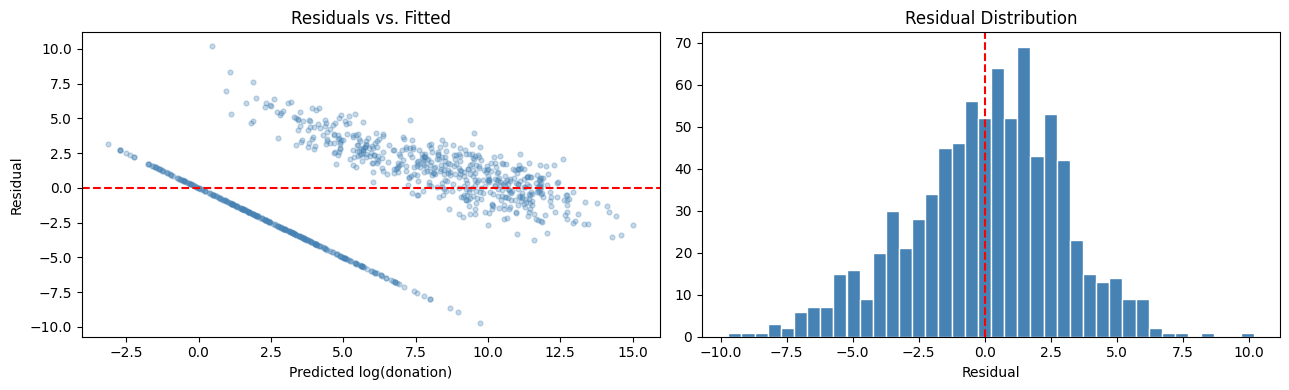

In [22]:
# Residual plots
residuals = y.values - y_pred_log

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(y_pred_log, residuals, alpha=0.3, s=12, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--', lw=1.5)
axes[0].set_xlabel('Predicted log(donation)')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs. Fitted')

axes[1].hist(residuals, bins=40, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', lw=1.5)
axes[1].set_xlabel('Residual')
axes[1].set_title('Residual Distribution')

plt.tight_layout()
plt.savefig('residuals_09.png', dpi=120, bbox_inches='tight')
plt.show()

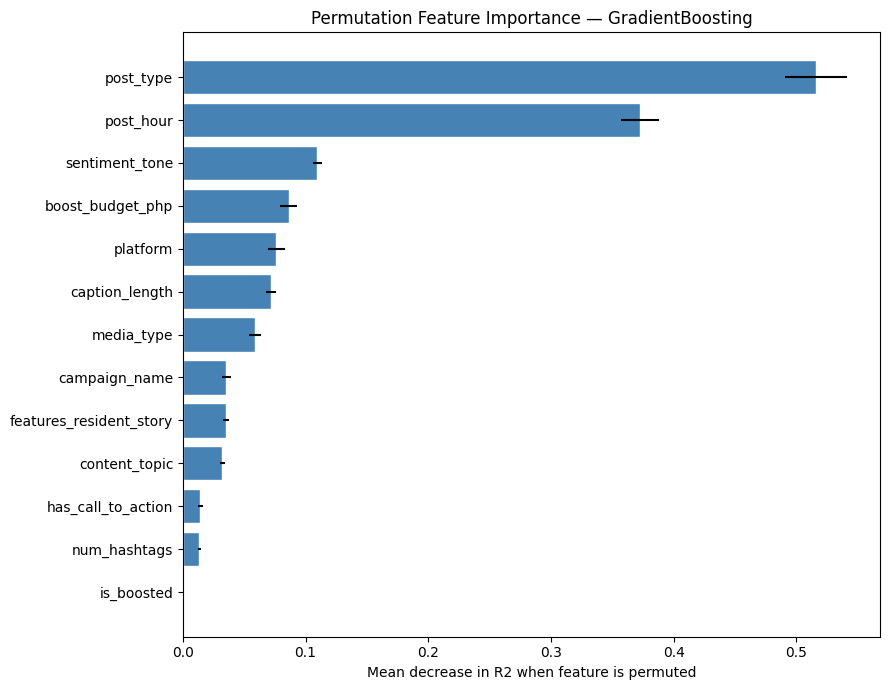

                feature  importance      std
              post_type    0.516043 0.025205
              post_hour    0.372950 0.015558
         sentiment_tone    0.109546 0.003719
       boost_budget_php    0.086102 0.006798
               platform    0.076191 0.006701
         caption_length    0.071834 0.004131
             media_type    0.058838 0.004844
          campaign_name    0.035441 0.003589
features_resident_story    0.035070 0.002764
          content_topic    0.032006 0.002065
     has_call_to_action    0.014222 0.002169
           num_hashtags    0.013441 0.001370
             is_boosted    0.000102 0.000084


In [23]:
# Permutation feature importance
from sklearn.inspection import permutation_importance

best_pipeline.fit(X, y)

perm = permutation_importance(
    best_pipeline, X, y,
    n_repeats=10, random_state=42, n_jobs=-1, scoring='r2',
)

perm_df = pd.DataFrame({
    'feature':    all_features,
    'importance': perm.importances_mean,
    'std':        perm.importances_std,
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(perm_df['feature'], perm_df['importance'],
        xerr=perm_df['std'], color='steelblue', edgecolor='white')
ax.invert_yaxis()
ax.set_xlabel('Mean decrease in R2 when feature is permuted')
ax.set_title(f'Permutation Feature Importance — {best_name}')
plt.tight_layout()
plt.savefig('importance_09.png', dpi=120, bbox_inches='tight')
plt.show()

print(perm_df.to_string(index=False))

### Limitations

**Target variable quality:**
`estimated_donation_value_php` is platform-reported and may differ from actual donor payments.
The model predicts platform estimates, not verified cash receipts.

**Engagement feature timing:**
Features like `impressions`, `reach`, and `engagement_rate` are only available after a post
has been live for some time. Predictions using these reflect in-flight projections, not
pre-publication forecasts. Pre-publication features (platform, post_type, is_boosted, etc.)
form a weaker but genuinely prospective predictor set.

**Campaign overlap:**
Only 4 campaign names exist. `campaign_name` acts more as a context tag than a true predictor;
its effect is partially confounded with the time-period of each campaign.

**Zero-inflation:**
Many posts raise ₱0. The log1p transform helps, but a two-stage model (classifier for ₱0 vs.
>₱0, then regressor on positives) could outperform a single regression if the proportion of
zero-value posts is large.

### Business Interpretation

**High feature importance for `impressions` / `reach`:**
Organic and paid reach is the primary driver of fundraising value. Boosting posts with
strong early organic engagement will likely yield the highest ROI.

**`engagement_rate` vs. raw counts:**
If engagement rate ranks above raw counts, quality of audience interaction matters as much
as volume — a smaller but highly engaged audience can outperform high-impression posts
with passive viewers.

**Platform and content type:**
If `platform` ranks highly, concentrate boosting budget on top-performing platforms.
If `post_type=FundraisingAppeal` scores high, increasing the ratio of direct ask posts
during campaign windows is actionable.

**Resident story flag:**
If `features_resident_story` shows positive importance, documenting and sharing more
survivor stories is a low-cost, high-return content strategy.

## Section 5 - Deployment & Integration

**Deployment Architecture:** Pre-computed predictions written to PostgreSQL.

The model is deployed as an offline batch pipeline:
1. A scheduled job pulls the latest `social_media_posts` rows.
2. The saved model pipeline scores each post and returns a predicted donation value in PHP.
3. Predictions are written to a `post_predictions` table consumed by the admin dashboard.
4. The dashboard displays predicted vs. actual fundraising per post, flagging underperformers
   for manual review.

**Integration point:** The React frontend reads predictions via the existing `/api/reports`
endpoint. A campaign effectiveness panel shows the model estimate alongside actual recorded
donations, giving fundraising staff a real-time gap view.

In [24]:
import joblib

best_pipeline.fit(X, y)

model_path = '../artifacts/campaign_funding.sav'
joblib.dump(best_pipeline, model_path)
print(f'Model saved to: {model_path}')

Model saved to: ../artifacts/campaign_funding.sav


In [25]:
# Example: score a single post
sample = pd.DataFrame([{
    'boost_budget_php':        5000,
    'num_hashtags':            4,
    'caption_length':          180,
    'post_hour':               18,
    'impressions':             8000,
    'reach':                   5500,
    'engagement_rate':         0.12,
    'is_boosted':              1,
    'has_call_to_action':      1,
    'features_resident_story': 1,
    'platform':                'Facebook',
    'post_type':               'FundraisingAppeal',
    'media_type':              'Photo',
    'content_topic':           'DonorImpact',
    'sentiment_tone':          'Emotional',
    'campaign_name':           'Year-End Hope',
}])

log_pred = best_pipeline.predict(sample)[0]
php_pred = np.expm1(log_pred)
print(f'Predicted donation value: {php_pred:,.2f} PHP')

Predicted donation value: 234,711.18 PHP


In [26]:
# Score all posts and write predictions to CSV for API integration
df['predicted_donation_value_php'] = np.expm1(best_pipeline.predict(X))

output = df[['post_id', 'platform', 'campaign_name', 'post_type',
             'estimated_donation_value_php', 'predicted_donation_value_php']].copy()
output['prediction_error_php'] = (output['estimated_donation_value_php']
                                   - output['predicted_donation_value_php'])

output.to_csv('../artifacts/campaign_funding_predictions.csv', index=False)
print(f'Predictions saved: {len(output)} rows')
print(output.head(10).to_string(index=False))

Predictions saved: 812 rows
 post_id  platform campaign_name          post_type  estimated_donation_value_php  predicted_donation_value_php  prediction_error_php
     318  WhatsApp           NaN  FundraisingAppeal                      21473.25                   4669.971113          16803.278887
     529 Instagram           NaN EducationalContent                       4708.45                    113.092040           4595.357960
      86  LinkedIn           NaN     EventPromotion                          0.00                      0.307710             -0.307710
     380 Instagram           NaN           ThankYou                          0.00                     42.904314            -42.904314
     425    TikTok           NaN           ThankYou                       8351.49                    652.416456           7699.073544
     807 Instagram           NaN     EventPromotion                       3516.65                    760.688085           2755.961915
     757  Facebook           NaN  